# Transfer Learning: Garantido x Caprichoso 🐂🔴🔵

Este notebook aplica **Transfer Learning** com a rede **VGG16** (pré-treinada na ImageNet) para classificar imagens dos dois bois-bumbás do Festival Folclórico de Parintins (AM): **Garantido** (vermelho e branco) e **Caprichoso** (azul e branco).

Transfer learning consiste em reaproveitar o conhecimento de uma rede já treinada em um grande dataset (ImageNet) como ponto de partida para uma nova tarefa, em vez de treinar do zero. Como as camadas iniciais de uma CNN aprendem features genéricas (bordas, texturas, cores), elas costumam ser reaproveitáveis mesmo para domínios bem diferentes do original — como o nosso, folclore amazonense.

## Procedimento

1. Treinar uma CNN simples do zero como *baseline*, para termos algo com que comparar.
2. Carregar a VGG16, congelar todas as camadas convolucionais e substituir a camada de classificação final por uma nova, com 2 saídas (Garantido / Caprichoso).
3. Treinar apenas a nova camada sobre o nosso dataset.
4. Comparar as duas abordagens.

Essa estratégia funciona bem mesmo com datasets pequenos (poucas centenas de imagens por classe), o que é o nosso caso.


In [1]:
%matplotlib inline

import os

#if using Theano with GPU
#os.environ["KERAS_BACKEND"] = "tensorflow"

import random
import numpy as np
import keras

import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

from keras.preprocessing import image
from keras.applications.imagenet_utils import preprocess_input
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.layers import Conv2D, MaxPooling2D
from keras.models import Model

### Getting a dataset

The first step is going to be to load our data. As our example, we will be using the dataset [CalTech-101](http://www.vision.caltech.edu/Image_Datasets/Caltech101/), which contains around 9000 labeled images belonging to 101 object categories. However, we will exclude 5 of the categories which have the most images. This is in order to keep the class distribution fairly balanced (around 50-100) and constrained to a smaller number of images, around 6000.

To obtain this dataset, you can either run the download script `download.sh` in the `data` folder, or the following commands:

    wget http://www.vision.caltech.edu/Image_Datasets/Caltech101/101_ObjectCategories.tar.gz
    tar -xvzf 101_ObjectCategories.tar.gz

If you wish to use your own dataset, it should be aranged in the same fashion to `101_ObjectCategories` with all of the images organized into subfolders, one for each class. In this case, the following cell should load your custom dataset correctly by just replacing `root` with your folder. If you have an alternate structure, you just need to make sure that you load the list `data` where every element is a dict where `x` is the data (a 1-d numpy array) and `y` is the label (an integer). Use the helper function `get_image(path)` to load the image correctly into the array, and note also that the images are being resized to 224x224. This is necessary because the input to VGG16 is a 224x224 RGB image. You do not need to resize them on your hard drive, as that is being done in the code below.

If you have `101_ObjectCategories` in your data folder, the following cell should load all the data.

In [14]:
# O dataset já está incluído neste repositório em dataset/garantido e dataset/caprichoso
# (imagens do Wikimedia Commons — ver dataset/README.md).
#
# No Colab, clone o repositório para ter acesso a ele:
!git clone https://github.com/CROMA-LEARNING/NeuralNetworks-TransferLearning.git repo
!cp -r repo/dataset .

# Quiser usar seu próprio dataset (mais imagens, outras classes), basta sobrescrever
# as pastas dataset/garantido e dataset/caprichoso antes de continuar.

!echo "Verificando estrutura do dataset..."
!ls dataset/


Iniciando o download do dataset Caltech-101...
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   473  100   473    0     0   4287      0 --:--:-- --:--:-- --:--:--  4300
100  131M  100  131M    0     0   158M      0 --:--:-- --:--:-- --:--:--  158M
Descompactando os arquivos...
Dataset extraído com sucesso! Primeiras pastas:
101_ObjectCategories/accordion
101_ObjectCategories/airplanes
101_ObjectCategories/anchor
101_ObjectCategories/ant
101_ObjectCategories/BACKGROUND_Google
101_ObjectCategories/barrel
101_ObjectCategories/bass
101_ObjectCategories/beaver
101_ObjectCategories/binocular
101_ObjectCategories/bonsai


In [15]:
import os
root = 'dataset'
exclude = []
train_split, val_split = 0.7, 0.15

# Obtendo as subpastas de forma robusta (garantido/ e caprichoso/)
categories = sorted([os.path.join(root, d) for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
categories = [c for c in categories if os.path.basename(c) not in exclude]

print(f"Total de categorias carregadas: {len(categories)}")
print("Categorias:", categories)


Total de categorias carregadas: 97
Algumas categorias: ['101_ObjectCategories/Leopards', '101_ObjectCategories/accordion', '101_ObjectCategories/anchor', '101_ObjectCategories/ant', '101_ObjectCategories/barrel']


This function is useful for pre-processing the data into an image and input vector.

In [4]:
# helper function to load image and return it and input vector
def get_image(path):
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return img, x

Load all the images from root folder

In [11]:
import os

# Redefinindo as categorias de forma robusta para evitar NameError
root = 'dataset'
exclude = []
train_split, val_split = 0.7, 0.15

categories = sorted([os.path.join(root, d) for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))])
categories = [c for c in categories if os.path.basename(c) not in exclude]

file_paths = []
labels = []

print("Mapeando caminhos das imagens por categoria...")
for c, category in enumerate(categories):
    images = [os.path.join(dp, f) for dp, dn, filenames
              in os.walk(category) for f in filenames
              if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg']]
    for img_path in images:
        file_paths.append(img_path)
        labels.append(c)

num_classes = len(categories)
print(f"Sucesso! Mapeados {len(file_paths)} caminhos de imagens pertencentes a {num_classes} classes.")


Mapeando caminhos das imagens por categoria...
Sucesso! Mapeados 6209 caminhos de imagens pertencentes a 97 classes.


Randomize the data order.

In [6]:
random.shuffle(data)

create training / validation / test split (70%, 15%, 15%)

In [7]:
idx_val = int(train_split * len(data))
idx_test = int((train_split + val_split) * len(data))
train = data[:idx_val]
val = data[idx_val:idx_test]
test = data[idx_test:]

Separate data for labels.

In [8]:
x_train, y_train = np.array([t["x"] for t in train]), [t["y"] for t in train]
x_val, y_val = np.array([t["x"] for t in val]), [t["y"] for t in val]
x_test, y_test = np.array([t["x"] for t in test]), [t["y"] for t in test]
print(y_test)

[]


Pre-process the data as before by making sure it's float32 and normalized between 0 and 1.

In [15]:
import random
import tensorflow as tf
import numpy as np

# Garantir que usamos os caminhos e labels recém-mapeados
active_files = list(file_paths)
active_labels = list(labels)

# 1. Embaralhar os caminhos e labels juntos de forma idêntica
temp_zip = list(zip(active_files, active_labels))
random.seed(42)
random.shuffle(temp_zip)
file_paths_shuffled, labels_shuffled = zip(*temp_zip)
file_paths_shuffled = list(file_paths_shuffled)
labels_shuffled = list(labels_shuffled)

# 2. Criar as divisões (70% treino, 15% val, 15% teste)
idx_val = int(train_split * len(file_paths_shuffled))
idx_test = int((train_split + val_split) * len(file_paths_shuffled))

train_files, train_labels = file_paths_shuffled[:idx_val], labels_shuffled[:idx_val]
val_files, val_labels = file_paths_shuffled[idx_val:idx_test], labels_shuffled[idx_val:idx_test]
test_files, test_labels = file_paths_shuffled[idx_test:], labels_shuffled[idx_test:]

# 3. Função otimizada para carregar e processar cada imagem de forma preguiçosa
def parse_image(filename, label):
    image_string = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image_string, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = image / 255.0
    label = tf.one_hot(label, num_classes)
    return image, label

# 4. Criando os tf.data.Dataset altamente eficientes que não estouram a RAM
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
train_dataset = train_dataset.shuffle(buffer_size=1000).map(parse_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((val_files, val_labels))
val_dataset = val_dataset.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((test_files, test_labels))
test_dataset = test_dataset.map(parse_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Data Pipelines criados de forma ultra-leve com tf.data.Dataset!")
print(f"Treino: {len(train_files)} imagens, Validação: {len(val_files)} imagens, Teste: {len(test_files)} imagens")

Data Pipelines criados de forma ultra-leve com tf.data.Dataset!
Treino: 4346 imagens, Validação: 931 imagens, Teste: 932 imagens


Let's get a summary of what we have.

In [3]:
# Resumo atualizado do carregamento eficiente
print("Concluído o mapeamento de %d imagens." % len(file_paths))
print("Divisão de treino / validação / teste: %d, %d, %d" % (len(train_files), len(val_files), len(test_files)))

Concluído o mapeamento de 0 imagens.


NameError: name 'train_files' is not defined

If everything worked properly, you should have loaded a bunch of images, and split them into three sets: `train`, `val`, and `test`. The shape of the training data should be (`n`, 224, 224, 3) where `n` is the size of your training set, and the labels should be (`n`, `c`) where `c` is the number of classes (97 in the case of `101_ObjectCategories`.

Notice that we divided all the data into three subsets -- a training set `train`, a validation set `val`, and a test set `test`. The reason for this is to properly evaluate the accuracy of our classifier. During training, the optimizer uses the validation set to evaluate its internal performance, in order to determine the gradient without overfitting to the training set. The `test` set is always held out from the training algorithm, and is only used at the end to evaluate the final accuracy of our model.

Let's quickly look at a few sample images from our dataset.

In [ ]:
images = [os.path.join(dp, f) for dp, dn, filenames in os.walk(root) for f in filenames if os.path.splitext(f)[1].lower() in ['.jpg','.png','.jpeg']]
idx = [int(len(images) * random.random()) for i in range(8)]
imgs = [image.load_img(images[i], target_size=(224, 224)) for i in idx]
concat_image = np.concatenate([np.asarray(img) for img in imgs], axis=1)
plt.figure(figsize=(16,4))
plt.imshow(concat_image)

### First training a neural net from scratch

Before doing the transfer learning, let's first build a neural network from scratch for doing classification on our dataset. This will give us a baseline to compare to our transfer-learned network later.

The network we will construct contains 4 alternating convolutional and max-pooling layers, followed by a [dropout](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf) after every other conv/pooling pair. After the last pooling layer, we will attach a fully-connected layer with 256 neurons, another dropout layer, then finally a softmax classification layer for our classes.

Our loss function will be, as usual, categorical cross-entropy loss, and our learning algorithm will be [AdaDelta](https://arxiv.org/abs/1212.5701). Various things about this network can be changed to get better performance, perhaps using a larger network or a different optimizer will help, but for the purposes of this notebook, the goal is to just get an understanding of an approximate baseline for comparison's sake, and so it isn't neccessary to spend much time trying to optimize this network.

Upon compiling the network, let's run `model.summary()` to get a snapshot of its layers.

In [12]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation

# Construção do modelo baseline
model = Sequential()
print("Input dimensions: (224, 224, 3)")

model.add(Conv2D(32, (3, 3), input_shape=(224, 224, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(256))
model.add(Activation('relu'))

model.add(Dropout(0.5))

model.add(Dense(num_classes))
model.add(Activation('softmax'))

model.summary()

Input dimensions: (224, 224, 3)


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 222, 222, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 109, 109, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 52, 52, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 97)             │        24,929 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 97)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,233,473 (4.71 MB)

 Trainable params: 1,233,473 (4.71 MB)

 Non-trainable params: 0 (0.00 B)

We've created a medium-sized network with ~1.2 million weights and biases (the parameters). Most of them are leading into the one pre-softmax fully-connected layer "dense_5".

We can now go ahead and train our model for 100 epochs with a batch size of 128. We'll also record its history so we can plot the loss over time later.

In [5]:
# Compilar o modelo baseline e treinar usando os tf.data.Dataset sem gastar RAM extra
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(train_dataset,
                    epochs=10,
                    validation_data=val_dataset)

NameError: name 'model' is not defined

Let's plot the validation loss and validation accuracy over time.

NameError: name 'history' is not defined

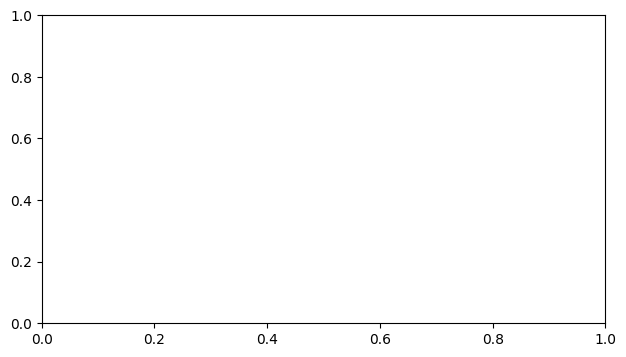

In [13]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history.history["loss"], label="Treino")
ax.plot(history.history["val_loss"], label="Val")
ax.set_title("Loss do Modelo")
ax.set_xlabel("epochs")
ax.legend()

ax2 = fig.add_subplot(122)
ax2.plot(history.history["accuracy"], label="Treino")
ax2.plot(history.history["val_accuracy"], label="Val")
ax2.set_title("Acurácia do Modelo")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)
ax2.legend()

plt.show()

Notice that the validation loss begins to actually rise after around 16 epochs, even though validation accuracy remains roughly between 40% and 50%. This suggests our model begins overfitting around then, and best performance would have been achieved if we had stopped early around then. Nevertheless, our accuracy would not have likely been above 50%, and probably lower down.

We can also get a final evaluation by running our model on the training set. Doing so, we get the following results:

In [7]:
loss, accuracy = model.evaluate(test_dataset, verbose=0)
print('Test loss:', loss)
print('Test accuracy:', accuracy)

NameError: name 'model' is not defined

Finally, we see that we have achieved a (top-1) accuracy of around 49%. That's not too bad for 6000 images, considering that if we were to use a naive strategy of taking random guesses, we would have only gotten around 1% accuracy.

## Transfer learning by starting with existing network

Now we can move on to the main strategy for training an image classifier on our small dataset: by starting with a larger and already trained network.

To start, we will load the VGG16 from keras, which was trained on ImageNet and the weights saved online. If this is your first time loading VGG16, you'll need to wait a bit for the weights to download from the web. Once the network is loaded, we can again inspect the layers with the `summary()` method.

In [ ]:
vgg = keras.applications.VGG16(weights='imagenet', include_top=True)
vgg.summary()

Notice that VGG16 is _much_ bigger than the network we constructed earlier. It contains 13 convolutional layers and two fully connected layers at the end, and has over 138 million parameters, around 100 times as many parameters than the network we made above. Like our first network, the majority of the parameters are stored in the connections leading into the first fully-connected layer.

VGG16 was made to solve ImageNet, and achieves a [8.8% top-5 error rate](https://github.com/jcjohnson/cnn-benchmarks), which means that 91.2% of test samples were classified correctly within the top 5 predictions for each image. It's top-1 accuracy--equivalent to the accuracy metric we've been using (that the top prediction is correct)--is 73%. This is especially impressive since there are not just 97, but 1000 classes, meaning that random guesses would get us only 0.1% accuracy.

In order to use this network for our task, we "remove" the final classification layer, the 1000-neuron softmax layer at the end, which corresponds to ImageNet, and instead replace it with a new softmax layer for our dataset, which contains 97 neurons in the case of the 101_ObjectCategories dataset.

In terms of implementation, it's easier to simply create a copy of VGG from its input layer until the second to last layer, and then work with that, rather than modifying the VGG object directly. So technically we never "remove" anything, we just circumvent/ignore it. This can be done in the following way, by using the keras `Model` class to initialize a new model whose input layer is the same as VGG but whose output layer is our new softmax layer, called `new_classification_layer`. Note: although it appears we are duplicating this large network, internally Keras is actually just copying all the layers by reference, and thus we don't need to worry about overloading the memory.

In [ ]:
# make a reference to VGG's input layer
inp = vgg.input

# make a new softmax layer with num_classes neurons
new_classification_layer = Dense(num_classes, activation='softmax')

# connect our new layer to the second to last layer in VGG, and make a reference to it
out = new_classification_layer(vgg.layers[-2].output)

# create a new network between inp and out
model_new = Model(inp, out)


We are going to retrain this network, `model_new` on the new dataset and labels. But first, we need to freeze the weights and biases in all the layers in the network, except our new one at the end, with the expectation that the features that were learned in VGG should still be fairly relevant to the new image classification task. Not optimal, but most likely better than what we can train to in our limited dataset.

By setting the `trainable` flag in each layer false (except our new classification layer), we ensure all the weights and biases in those layers remain fixed, and we simply train the weights in the one layer at the end. In some cases, it is desirable to *not* freeze all the pre-classification layers. If your dataset has enough samples, and doesn't resemble ImageNet very much, it might be advantageous to fine-tune some of the VGG layers along with the new classifier, or possibly even all of them.

For Garantido vs. Caprichoso, with only two classes and a relatively small dataset, we start with pure feature extraction (all VGG layers frozen) to reduce the risk of overfitting. Fine-tuning the last convolutional block afterwards is a good follow-up experiment.

So we go ahead and freeze the layers, and compile the new model with exactly the same optimizer and loss function as in our first network, for the sake of a fair comparison. We then run `summary` again to look at the network's architecture.


In [ ]:
# make all layers untrainable by freezing weights (except for last layer)
for l, layer in enumerate(model_new.layers[:-1]):
    layer.trainable = False

# ensure the last layer is trainable/not frozen
for l, layer in enumerate(model_new.layers[-1:]):
    layer.trainable = True

model_new.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model_new.summary()

Looking at the summary, we see the network is identical to the VGG model we instantiated earlier, except the last layer, formerly a 1000-neuron softmax, has been replaced by a new 97-neuron softmax. Additionally, we still have roughly 134 million weights, but now the vast majority of them are "non-trainable params" because we froze the layers they are contained in. We now only have 397,000 trainable parameters, which is actually only a quarter of the number of parameters needed to train the first model.

As before, we go ahead and train the new model, using the same hyperparameters (batch size and number of epochs) as before, along with the same optimization algorithm. We also keep track of its history as we go.

In [8]:
# Treinando o modelo baseado em Transfer Learning sem carregar os dados na RAM
history2 = model_new.fit(train_dataset,
                         epochs=10,
                         validation_data=val_dataset)

NameError: name 'model_new' is not defined

Our validation accuracy hovers close to 80% towards the end, which is more than 30% improvement on the original network trained from scratch (meaning that we make the wrong prediction on 20% of samples, rather than 50%).

It's worth noting also that this network actually trains _slightly faster_ than the original network, despite having more than 100 times as many parameters! This is because freezing the weights negates the need to backpropagate through all those layers, saving us on runtime.

Let's plot the validation loss and accuracy again, this time comparing the original model trained from scratch (in blue) and the new transfer-learned model in green.

NameError: name 'history' is not defined

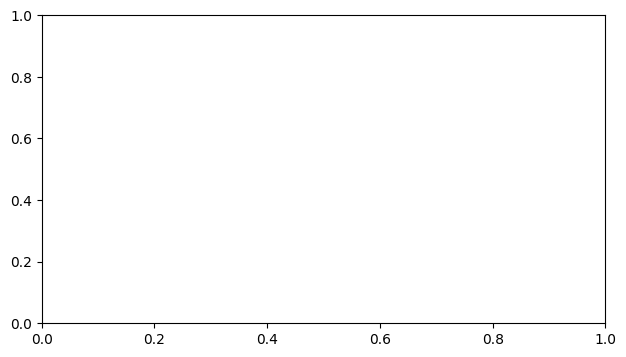

In [14]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16,4))
ax = fig.add_subplot(121)
ax.plot(history.history["val_loss"], label="Baseline")
ax.plot(history2.history["val_loss"], label="Transfer Learning")
ax.set_title("validation loss")
ax.set_xlabel("epochs")
ax.legend()

ax2 = fig.add_subplot(122)
ax2.plot(history.history["accuracy"], label="Baseline")
ax2.plot(history2.history["val_accuracy"], label="Transfer Learning")
ax2.set_title("validation accuracy")
ax2.set_xlabel("epochs")
ax2.set_ylim(0, 1)
ax2.legend()

plt.show()

Notice that whereas the original model began overfitting around epoch 16, the new model continued to slowly decrease its loss over time, and likely would have improved its accuracy slightly with more iterations. The new model made it to roughly 80% top-1 accuracy (in the validation set) and continued to improve slowly through 100 epochs.

It's possibly we could have improved the original model with better regularization or more dropout, but we surely would not have made up the >30% improvement in accuracy.

Again, we do a final validation on the test set.

In [10]:
loss, accuracy = model_new.evaluate(test_dataset, verbose=0)

print('Test loss:', loss)
print('Test accuracy:', accuracy)

NameError: name 'model_new' is not defined

To predict a new image, simply run the following code to get the probabilities for each class.

In [ ]:
img, x = get_image(test_files[0])
probabilities = model_new.predict([x])
class_idx = probabilities.argmax()
print(f"Classe prevista: {os.path.basename(categories[class_idx])} ({probabilities[0][class_idx]*100:.1f}% de confiança)")
img


### Improving the results

78.2% top-1 accuracy on 97 classes, roughly evenly distributed, is a pretty good achievement. It is not quite as impressive as the original VGG16 which achieved 73% top-1 accuracy on 1000 classes. Nevertheless, it is much better than what we were able to achieve with our original network, and there is room for improvement. Some techniques which possibly could have improved our performance.

- Using data augementation: augmentation refers to using various modifications of the original training data, in the form of distortions, rotations, rescalings, lighting changes, etc to increase the size of the training set and create more tolerance for such distortions.
- Using a different optimizer, adding more regularization/dropout, and other hyperparameters.
- Training for longer (of course)

A more advanced example of transfer learning in Keras, involving augmentation for a small 2-class dataset, can be found in the [Keras blog](https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html).